## TP 3: Clasificando de pobres con la EPH.


Grupo 1: Francisco Leiva, Juan Cabrera y Agustín Rivas Bergant

### Paquetes y descarga de las bases

In [1]:
# Paquetes empleados
import os 
import pandas as pd # Manipulacion de datos
import numpy as np # Calculos numericos
import matplotlib.pyplot as plt # Graficos
import seaborn as sns # Grafico
import statsmodels.api as sm     
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, recall_score 
from sklearn.metrics import RocCurveDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler # Estandarizacion de datos

### Apartado A) ENFOQUE DE VALIDACIÓN

In [2]:
# IMPORTAMOS LAS BASES
#C:\Users\Usuario\Desktop\Maestria\Programacion\BigDataUBA-Grupo1\TP3\bases - Ruta juan pc escritorio
#r"C:\Users\AGUSTIN\Desktop\TP" - Ruta Agus
# C:\Repositorios\BigDataUBA-Grupo1\TP3\bases - Ruta Fran

base_path = r"C:\Repositorios\BigDataUBA-Grupo1\TP3\bases"

files = {
    "respondieron_2005": "respondieron_2005.xlsx",
    "respondieron_2025": "respondieron_2025.xlsx",
    "norespondieron_2005": "norespondieron_2005.xlsx",
    "norespondieron_2025": "norespondieron_2025.xlsx",
}

# LECTURA DE LOS EXCELS
dfs = {}

for key, fname in files.items():
    full_path = os.path.join(base_path, fname)
    print(f"Leyendo: {full_path}")
    dfs[key] = pd.read_excel(full_path)
    print(f" → {key}: {dfs[key].shape}")

del full_path, key, fname, files

Leyendo: C:\Repositorios\BigDataUBA-Grupo1\TP3\bases\respondieron_2005.xlsx
 → respondieron_2005: (3206, 44)
Leyendo: C:\Repositorios\BigDataUBA-Grupo1\TP3\bases\respondieron_2025.xlsx
 → respondieron_2025: (4157, 44)
Leyendo: C:\Repositorios\BigDataUBA-Grupo1\TP3\bases\norespondieron_2005.xlsx
 → norespondieron_2005: (23, 44)
Leyendo: C:\Repositorios\BigDataUBA-Grupo1\TP3\bases\norespondieron_2025.xlsx
 → norespondieron_2025: (1202, 44)


In [3]:
# VARIABLES EXPLICATIVAS
vars_X = [
    "educ", "CH06", "edad2", "horastrab",
    "CH04", "IX_TOT", "CH07",
    "CH08", "ESTADO"
]

# DIVIDIMOS EN TRAIN/TEST
def dividir_train_test(df):
    df = df.copy()

    # Matriz X
    X = df[vars_X]

    # Agregar intercepto
    X = X.assign(intercepto=1)

    # Variable dependiente
    y = df["pobre"]

    # Corte 70/30
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, random_state=444
    )

    return X_train, X_test, y_train, y_test

# VERIFICACIÓN DE TAMAÑO DE LAS BASES FINALES
Xtr_2005, Xte_2005, ytr_2005, yte_2005 = dividir_train_test(dfs["respondieron_2005"])
Xtr_2025, Xte_2025, ytr_2025, yte_2025 = dividir_train_test(dfs["respondieron_2025"])

print("\nTamaños de los sets:")
print("2005 → Train:", Xtr_2005.shape, " Test:", Xte_2005.shape)
print("2025 → Train:", Xtr_2025.shape, " Test:", Xte_2025.shape)
print("2005 → Train:", ytr_2005.shape, " Test:", yte_2005.shape)
print("2025 → Train:", ytr_2025.shape, " Test:", yte_2025.shape)

del vars_X


Tamaños de los sets:
2005 → Train: (2244, 10)  Test: (962, 10)
2025 → Train: (2909, 10)  Test: (1248, 10)
2005 → Train: (2244,)  Test: (962,)
2025 → Train: (2909,)  Test: (1248,)


#### 1) TABLA DE DIFERENCIA DE MEDIAS 

In [4]:
# TABLA DE DIFERENCIAS DE MEDIAS TRAIN–TEST

def tabla_dif_medias(X_train, X_test):
    train_mean = X_train.mean()
    test_mean = X_test.mean()
    diff = train_mean - test_mean

    tabla = pd.DataFrame({
        "Media Train": train_mean,
        "Media Test": test_mean,
        "Diferencia (Train - Test)": diff
    })

    return tabla

# CREAR TABLAS
tabla_2005 = tabla_dif_medias(Xtr_2005, Xte_2005)
tabla_2025 = tabla_dif_medias(Xtr_2025, Xte_2025)

print("Diferencias 2005:")
print(tabla_2005)

print("\nDiferencias 2025:")
print(tabla_2025)

# GUARDAR EN EXCEL
salida = os.path.join(base_path, "diferencias_medias_train_test.xlsx")
with pd.ExcelWriter(salida) as writer:
    tabla_2005.to_excel(writer, sheet_name="2005")
    tabla_2025.to_excel(writer, sheet_name="2025")

print(f"\nArchivo guardado en: {salida}")

del tabla_2005, tabla_2025,  writer

Diferencias 2005:
            Media Train  Media Test  Diferencia (Train - Test)
educ           8.955385    8.873284                   0.082101
CH06          29.671123   29.567568                   0.103555
edad2         29.699643   29.525988                   0.173656
horastrab     15.746881   14.854470                   0.892411
CH04           1.517380    1.503119                   0.014261
IX_TOT         4.336007    4.436590                  -0.100583
CH07           3.553030    3.570686                  -0.017656
CH08           1.941176    1.907484                   0.033692
ESTADO         2.340018    2.375260                  -0.035242
intercepto     1.000000    1.000000                   0.000000

Diferencias 2025:
            Media Train  Media Test  Diferencia (Train - Test)
educ          10.722203   10.891217                  -0.169014
CH06          37.334135   38.341346                  -1.007211
edad2         37.330698   38.347756                  -1.017059
horastrab     15.6

### Apartado B) MODELO DE REGRESIÓN LOGISTICA


In [5]:
# COPIAMOS X E Y DE TRAIN 2025
X = Xtr_2025.copy()
y = ytr_2025.copy()

# UNIMOS PARA DROPEAR FILAS CON NAN
data_train = pd.concat([X, y], axis=1)

print("NaNs por columna antes de limpiar:")
print(data_train.isna().sum())

# DROPEAMOS FILAS CON NAN EN X O EN Y
data_clean = data_train.dropna(subset=['educ'])

print("\nTamaño antes:", data_train.shape)
print("Tamaño después de dropna:", data_clean.shape)

# SEPARAMOS X E Y Y AGISNAMOS TIPO FLOAT

X_clean = data_clean.drop(columns=["pobre"]).astype(float)
y_clean = data_clean["pobre"].astype(float)

# - MODELO LOGIT - ENTRENAMIENTO 

logit_model = sm.Logit(y_clean, X_clean)   # CREAMOOS EL OBJETO DEL MODELO LOGIT
result = logit_model.fit(disp=False)       # ESTIMAMOS EL MODELO 

print(result.summary())

NaNs por columna antes de limpiar:
educ          22
CH06           0
edad2          0
horastrab      0
CH04           0
IX_TOT         0
CH07           0
CH08           0
ESTADO         0
intercepto     0
pobre          0
dtype: int64

Tamaño antes: (2909, 11)
Tamaño después de dropna: (2887, 11)
                           Logit Regression Results                           
Dep. Variable:                  pobre   No. Observations:                 2887
Model:                          Logit   Df Residuals:                     2877
Method:                           MLE   Df Model:                            9
Date:                Tue, 18 Nov 2025   Pseudo R-squ.:                  0.1976
Time:                        15:11:18   Log-Likelihood:                -1246.4
converged:                       True   LL-Null:                       -1553.2
Covariance Type:            nonrobust   LLR p-value:                2.386e-126
                 coef    std err          z      P>|z|      [0.025    

#### 3) ESTIMACIÓN DE EFECTOS MARGINALES

In [6]:
# COEFICIENTES, ODDS RATIO Y ERRORES ESTÁNDAR
coef = result.params
se   = result.bse
odds = np.exp(result.params)

tabla_logit = pd.DataFrame({
    "Coeficiente": coef,
    "Error estándar": se,
    "Odds Ratio": odds
})

print("\nTabla logit 2025:")
print(tabla_logit)

# EXPORTAR A EXCEL
salida_logit = os.path.join(base_path, "logit_2025_coeficientes.xlsx")
tabla_logit.to_excel(salida_logit)
print(f"\nTabla exportada a: {salida_logit}")


Tabla logit 2025:
            Coeficiente  Error estándar  Odds Ratio
educ          -0.060154        0.013450    0.941619
CH06          -0.002902        0.025412    0.997102
edad2         -0.000573        0.025249    0.999427
horastrab     -0.012352        0.004676    0.987724
CH04           0.154559        0.103403    1.167143
IX_TOT         0.421083        0.033866    1.523610
CH07          -0.025347        0.039118    0.974971
CH08           0.504140        0.037031    1.655561
ESTADO        -0.052120        0.096279    0.949215
intercepto    -2.806005        0.510308    0.060446

Tabla exportada a: C:\Repositorios\BigDataUBA-Grupo1\TP3\bases\logit_2025_coeficientes.xlsx


#### 4) VISUALIZACIÓN

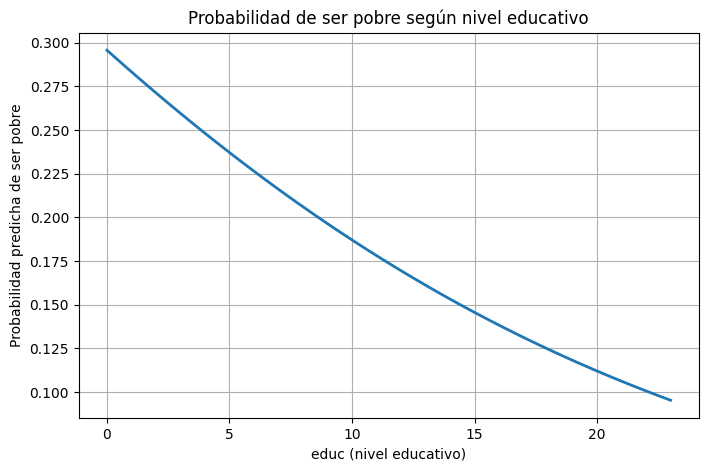

In [7]:
# VARIABLE NUMÉRICA A GRAFICAR
variable = "educ"  

# RANGO DE VALORES A GRAFICAR
x_vals = np.linspace(X_clean[variable].min(), X_clean[variable].max(), 100)

# TOMAMOS LAS MEDIAS DE TODAS LAS VARIABLES DE X_CLEAN
means = X_clean.mean()

# DATAFRAME DE 100 FILAS, TODAS IGUALES A LAS MEDIAS
X_plot = pd.DataFrame(
    np.tile(means.values, (100, 1)),
    columns=means.index
)

# REEMPLAZO EDUC POR LA GRILLA DE X_VALS
X_plot[variable] = x_vals

# PREDICCION
y_pred = result.predict(X_plot)

# GRAFICAR
plt.figure(figsize=(8,5))
plt.plot(x_vals, y_pred, linewidth=2)

plt.xlabel("educ (nivel educativo)")
plt.ylabel("Probabilidad predicha de ser pobre")
plt.title("Probabilidad de ser pobre según nivel educativo")
plt.grid(True)

plt.show()

In [8]:
# PREPARACIÓN DE TEST PARA LOGIT 

# TEST LIMPIO
data_test = pd.concat([Xte_2025, yte_2025], axis=1)

# ELIMINAMOS FILAS CON NAN
data_test_clean = data_test.dropna(subset=['educ'])

# SEPARAMOS
X_test_clean = data_test_clean.drop(columns=["pobre"]).astype(float)
y_test_clean = data_test_clean["pobre"].astype(float)

# PREDICCIONES
y_pred_prob = result.predict(X_test_clean)
y_pred = (y_pred_prob >= 0.5).astype(int)

# MÉTRICAS
from sklearn.metrics import confusion_matrix, classification_report

print("\nMatriz de Confusión TEST:")
print(confusion_matrix(y_test_clean, y_pred))

print("\nReporte de Clasificación TEST:")
print(classification_report(y_test_clean, y_pred))


Matriz de Confusión TEST:
[[929  53]
 [175  84]]

Reporte de Clasificación TEST:
              precision    recall  f1-score   support

         0.0       0.84      0.95      0.89       982
         1.0       0.61      0.32      0.42       259

    accuracy                           0.82      1241
   macro avg       0.73      0.64      0.66      1241
weighted avg       0.79      0.82      0.79      1241



### Apartado C) MODELO DE VECINOS CERCANOS

#### 5) ESTIMACIÓN

In [9]:
# PREPARACIÓN DE TEST EN KNN 

X_test_2025 = Xte_2025.copy()
y_test_2025 = yte_2025.copy()

# Unimos para dropear filas con NaN igual que hiciste en TRAIN
data_test = pd.concat([X_test_2025, y_test_2025], axis=1)

print("NaNs por columna en TEST antes de limpiar:")
print(data_test.isna().sum())

# Mismo criterio de limpieza que en training → usar 'educ'
data_test_clean = data_test.dropna(subset=['educ'])

print("\nTamaño TEST antes:", data_test.shape)
print("Tamaño TEST después de dropna:", data_test_clean.shape)

# SEPARAMOS X E Y DEL TEST LIMPIO
X_test_clean = data_test_clean.drop(columns=["pobre"])
y_test_clean = data_test_clean["pobre"]

# TIPO NUMÉRICO (igual que en train)
X_test_clean = X_test_clean.astype(float)
y_test_clean = y_test_clean.astype(float)

NaNs por columna en TEST antes de limpiar:
educ          7
CH06          0
edad2         0
horastrab     0
CH04          0
IX_TOT        0
CH07          0
CH08          0
ESTADO        0
intercepto    0
pobre         0
dtype: int64

Tamaño TEST antes: (1248, 11)
Tamaño TEST después de dropna: (1241, 11)


In [10]:
# SACAMOS EL INTERCEPTO
if "intercepto" in X_clean.columns:
    X_train_knn = X_clean.drop(columns=["intercepto"])
else:
    X_train_knn = X_clean.copy()

if "intercepto" in X_test_clean.columns:
    X_test_knn = X_test_clean.drop(columns=["intercepto"])
else:
    X_test_knn = X_test_clean.copy()

y_train_knn = y_clean.copy()
y_test_knn = y_test_clean.copy()

# Probar para distintos valores de K
for k in [1, 5, 10]:
    modelo_nombre = f'knn_k{k}'
    print(f'\n🔎 Entrenando {modelo_nombre}')
    
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_knn, y_train_knn)
    
    y_pred_train = knn.predict(X_train_knn)
    
    print('Accuracy:', accuracy_score(y_train_knn, y_pred_train))
    print('Matriz de confusión:\n', confusion_matrix(y_train_knn, y_pred_train))
    print('Reporte de clasificación:\n',
          classification_report(y_train_knn, y_pred_train,
                                target_names=['No pobre', 'Pobre']))


🔎 Entrenando knn_k1
Accuracy: 0.9639764461378594
Matriz de confusión:
 [[2174   52]
 [  52  609]]
Reporte de clasificación:
               precision    recall  f1-score   support

    No pobre       0.98      0.98      0.98      2226
       Pobre       0.92      0.92      0.92       661

    accuracy                           0.96      2887
   macro avg       0.95      0.95      0.95      2887
weighted avg       0.96      0.96      0.96      2887


🔎 Entrenando knn_k5
Accuracy: 0.8413578108763422
Matriz de confusión:
 [[2115  111]
 [ 347  314]]
Reporte de clasificación:
               precision    recall  f1-score   support

    No pobre       0.86      0.95      0.90      2226
       Pobre       0.74      0.48      0.58       661

    accuracy                           0.84      2887
   macro avg       0.80      0.71      0.74      2887
weighted avg       0.83      0.84      0.83      2887


🔎 Entrenando knn_k10
Accuracy: 0.8143401454797368
Matriz de confusión:
 [[2166   60]
 [ 476  

#### 6) VISUALIZACIÓN

In [12]:
# Preparo el gráfico utilizando como variables años de educación y horas trabajadas
X_train_viz = X_train_knn[['educ', 'horastrab']].copy()
X_test_viz  = X_test_knn[['educ', 'horastrab']].copy()

# Estandarizo los valores SOLO para el gráfico en 2D
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_viz)
X_test_scaled  = scaler.transform(X_test_viz)

# Entreno los modelos con k = 1 y k = 10
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train_scaled, y_train_knn)

knn10 = KNeighborsClassifier(n_neighbors=10)
knn10.fit(X_train_scaled, y_train_knn)

,n_neighbors,10
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [13]:
#Genero una funcion para encontrar los umbrales de decision y graficar
# Fondo: 0 = celeste (NO pobre), 1 = rosa (POBRE)
from matplotlib.colors import ListedColormap
cmap_background = ListedColormap(['#b3cde3', '#fbb4ae'])
def plot_decision_boundary(model, X, y, title, ax):
    h = 0.1  # paso de la grilla

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Crear una grilla de puntos
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    # Predecir clase para cada punto de la grilla
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Graficar frontera de decisión en el eje ax
    cont = ax.contourf(xx, yy, Z, cmap=cmap_background, alpha=0.8)
    # Barra de color
    cbar = plt.colorbar(cont, ax=ax)
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(['No pobre (0)', 'Pobre (1)'])

    # Graficar puntos verdaderos
    scatter = ax.scatter(
        X[:, 0], X[:, 1],
        c=y,
        cmap=plt.cm.coolwarm,
        edgecolor='k',
        s=20
    )

    ax.set_xlabel("Educación (estandarizada)")
    ax.set_ylabel("Horas trabajadas (estandarizadas)")
    ax.set_title(title)
    ax.legend(*scatter.legend_elements(), title="Pobre")
    ax.grid(False)


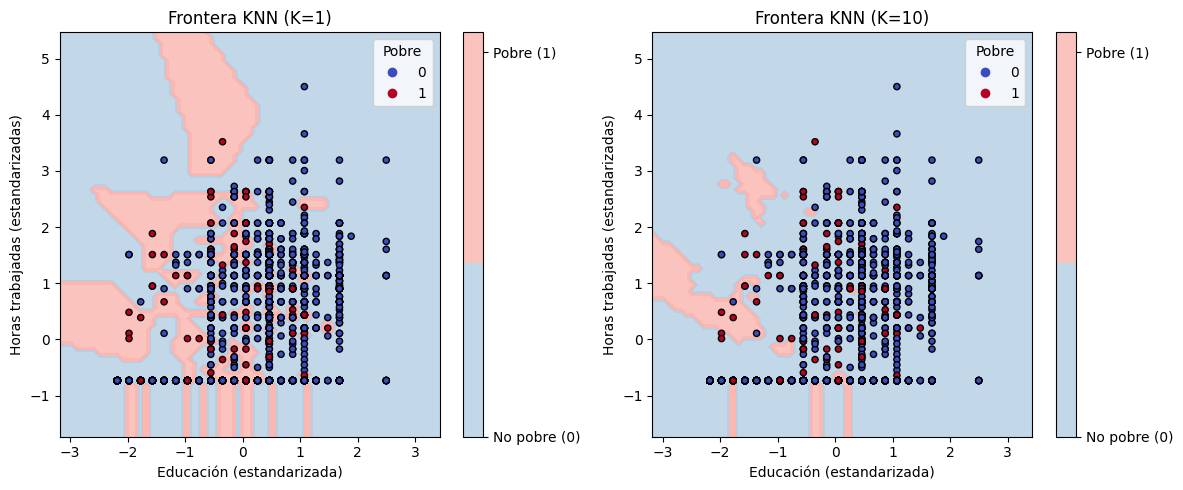

In [14]:
#Aca completamos el grafico de los dos modelos entrenados
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# K=1 sin colorbar
plot_decision_boundary(
    knn1,
    X_train_scaled,
    y_train_knn.values,
    "Frontera KNN (K=1)",
    axes[0],
)

# K=10 con colorbar
plot_decision_boundary(
    knn10,
    X_train_scaled,
    y_train_knn.values,
    "Frontera KNN (K=10)",
    axes[1],
)

plt.tight_layout()
plt.show()

#### 7) K OPTIMO POR CROSS-VALIDATION

In [15]:
# Preparo la separacion de X_train en 5 folds para hacer cross-validation
# Rango de valores de K
k_values = range(1, 11)  # K de 1 a 10

# Guardamos los puntajes promedio de cada K
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    
    # 5-fold cross-validation sobre los datos de entrenamiento
    # (acá solo cambio X_train, y_train → X_train_knn, y_train_knn)
    scores = cross_val_score(knn, X_train_knn, y_train_knn, cv=5, scoring='accuracy')
    
    # Promedio de los 5 folds
    cv_scores.append(scores.mean())

# Encontrar el K óptimo
best_k = k_values[np.argmax(cv_scores)]
print(f"✅ El mejor valor de K es: {best_k}")

✅ El mejor valor de K es: 10


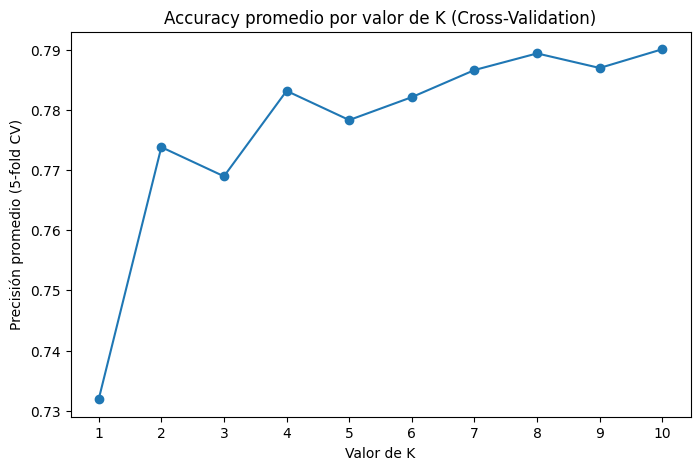

In [31]:
# Gráfico del accuracy de los diferentes valores de k
plt.figure(figsize=(8,5))
plt.plot(k_values, cv_scores, marker='o')
plt.xticks(k_values)
plt.xlabel("Valor de K")
plt.ylabel("Precisión promedio (5-fold CV)")
plt.title("Accuracy promedio por valor de K (Cross-Validation)")
plt.grid(False)
plt.show()

In [16]:
# Entrenar el modelo KNN con K óptimo
knn_cv = KNeighborsClassifier(n_neighbors=best_k)
knn_cv.fit(X_train_knn, y_train_knn)

,n_neighbors,10
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### Apartado D)  Desempeño de modelos afuera de la muestra, métricas y politicas públicas

In [17]:
# Recueprando los modelos entrenados:

# - MODELO LOGIT - ENTRENAMIENTO 

logit_model = sm.Logit(y_clean, X_clean)   # CREAMOOS EL OBJETO DEL MODELO LOGIT
result = logit_model.fit(disp=False)       # ESTIMAMOS EL MODELO 

## Set de datos de testeo 
# - MODELO KNN -

knn_cv = KNeighborsClassifier(n_neighbors=best_k)
knn_cv.fit(X_train_knn, y_train_knn)

##  Set de datos de testeo

# X_test_knn y_test_knn 


,n_neighbors,10
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [18]:
#Probar rendimiento en datasets de test
y_pred_cv = knn_cv.predict(X_test_knn)
print(confusion_matrix(y_test_knn, y_pred_cv))
print(classification_report(y_test_knn, y_pred_cv))

[[945  37]
 [193  66]]
              precision    recall  f1-score   support

         0.0       0.83      0.96      0.89       982
         1.0       0.64      0.25      0.36       259

    accuracy                           0.81      1241
   macro avg       0.74      0.61      0.63      1241
weighted avg       0.79      0.81      0.78      1241

